#Denoising Autoencoders (The Image "Cleaner")

**Logic:** If we train a model where the Input is a messy, noisy image and the Target is the original clean image, the model is forced to learn the underlying patterns (the "essence" of a digit) rather than just memorizing pixels.

1. Create Noisy Data

We take the standard MNIST dataset and intentionally corrupt it with random Gaussian noise.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load and normalize MNIST
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# 2. Add random "static" noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape) 
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape) 

# Ensure pixels stay in the [0, 1] range
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

2. The Convolutional Architecture

Yesterday we used Dense layers. Today, we use Conv2D because it understands spatial context (neighboring pixels), which is essential for distinguishing between "noise" and "object."

In [2]:
input_img = layers.Input(shape=(28, 28, 1))

# Encoder: Shrinking the image while finding features
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder: Blowing the image back up to 28x28
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Full Model
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 3. Train: Notice Input is NOISY, but Target is CLEAN
autoencoder.fit(x_train_noisy, x_train,
                epochs=10,
                batch_size=128,
                validation_data=(x_test_noisy, x_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - loss: 0.1564 - val_loss: 0.1164
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 80ms/step - loss: 0.1128 - val_loss: 0.1098
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 0.1070 - val_loss: 0.1047
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 80ms/step - loss: 0.1043 - val_loss: 0.1029
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - loss: 0.1025 - val_loss: 0.1010
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - loss: 0.1010 - val_loss: 0.0997
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 84ms/step - loss: 0.1000 - val_loss: 0.0992
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 85ms/step - loss: 0.0991 - val_loss: 0.0980
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 84ms/step - loss: 0.0984 - val_loss: 0.0979
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 101ms/step - loss: 0.0978 - val_loss: 0.0972


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


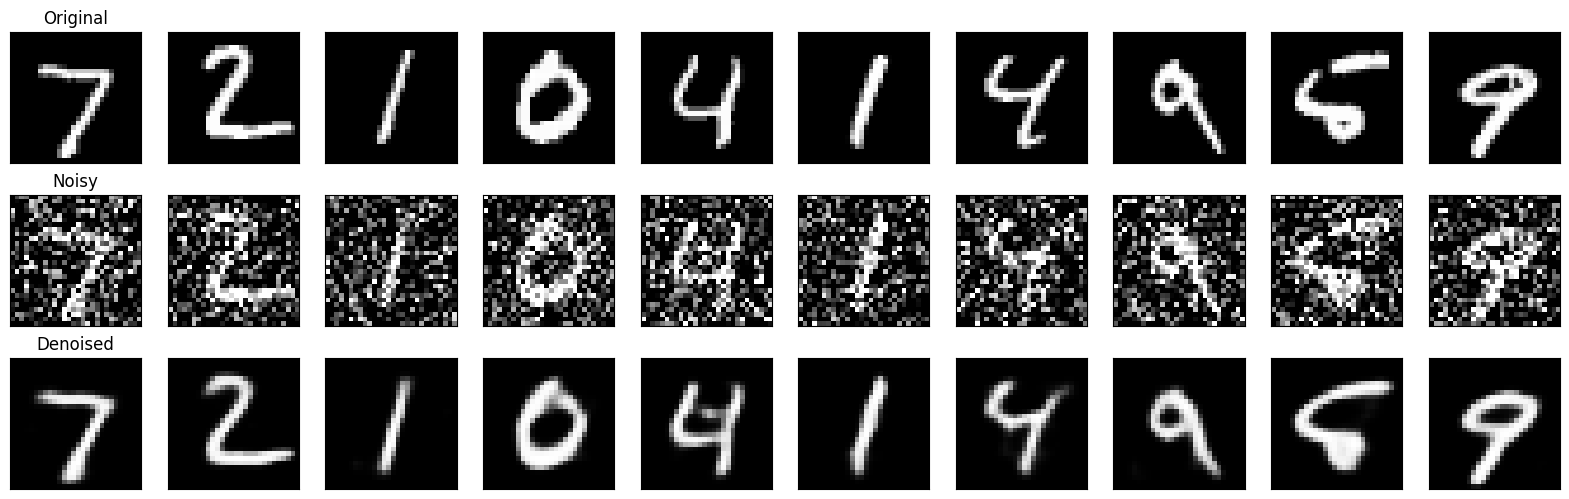

In [3]:
import matplotlib.pyplot as plt

# 1. Predict on the noisy test set
decoded_imgs = autoencoder.predict(x_test_noisy)

# 2. Plotting the results
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # a. Original (Clean)
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0: ax.set_title("Original")

    # b. Noisy (Input)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0: ax.set_title("Noisy")

    # c. Denoised (Output)
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0: ax.set_title("Denoised")

plt.show()